# Reproducibility and memory-bounded scaling

If you cannot reproduce a bootstrap result, you cannot cite it. `tsbootstrap` answers that on two fronts: a run is deterministic for a fixed seed and environment, and it records its own provenance. From there we scale to a large number of replicates without running out of memory, using `bootstrap_reduce`, which keeps only a per-replicate statistic instead of the full array of resampled series.

Throughout we simulate a stationary AR(1), `x[t] = phi * x[t-1] + e[t]`.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## A small AR(1) series

A stationary AR(1) with `phi = 0.6` and unit-variance Gaussian noise. We keep `n` small; the scaling demo later pushes the number of replicates, not the series length.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

PHI = 0.6


def ar1(n, phi=PHI, rng=None):
    """Stationary AR(1) with unit-variance Gaussian noise, started at 0."""
    rng = np.random.default_rng() if rng is None else rng
    x = np.zeros(n)
    e = rng.standard_normal(n)
    for t in range(1, n):
        x[t] = phi * x[t - 1] + e[t]
    return x


n = 120
x = ar1(n, PHI, np.random.default_rng(0))
x[:5]

array([ 0.        , -0.13210486,  0.56115973,  0.44159596, -0.2707118 ])

## Reproducibility: same seed, identical results

Pass an integer `random_state` and two runs return bitwise-identical arrays. The RNG contract is per-replicate: replicate `i` is bound to its own generator, derived from `SeedSequence.spawn(n)[i]`, before any work is dispatched. Because the stream for sample `i` is fixed before parallelisation, the results are invariant to the worker count and to how the replicates are chunked. We verify exact equality with `np.array_equal`.

In [3]:
from tsbootstrap import bootstrap, MovingBlock

run_a = bootstrap(x, method=MovingBlock(block_length=10), n_bootstraps=200, random_state=0)
run_b = bootstrap(x, method=MovingBlock(block_length=10), n_bootstraps=200, random_state=0)

values_equal = np.array_equal(run_a.values(), run_b.values())
indices_equal = np.array_equal(run_a.indices(), run_b.indices())
print(f'values identical across two random_state=0 runs: {values_equal}')
print(f'indices identical across two random_state=0 runs: {indices_equal}')

# A different seed gives a different draw (sanity check that the seed is doing something).
run_c = bootstrap(x, method=MovingBlock(block_length=10), n_bootstraps=200, random_state=1)
print(f'random_state=1 differs from random_state=0: {not np.array_equal(run_a.values(), run_c.values())}')

values identical across two random_state=0 runs: True
indices identical across two random_state=0 runs: True
random_state=1 differs from random_state=0: True


`random_state` accepts an `int`, a NumPy `Generator`, a `SeedSequence`, or `None`. An `int` (or a `SeedSequence`) gives a reproducible run for any worker count. A `Generator` is consumed once: a 128-bit seed is drawn from it and recorded, so the live generator is never shared across processes, yet the run is reproducible from the recorded entropy. `None` uses OS entropy (non-reproducible), but the drawn entropy is still recorded for provenance. The next cell shows where that recorded entropy lives.

Worker-count invariance is the same contract NumPy and scikit-learn give: results are reproducible for a fixed seed and environment (OS, hardware, BLAS, NumPy version).

## Provenance: the run records how it was produced

Every result carries a `BootstrapRunMetadata` record at `result.metadata`, which holds what you need to reproduce or cite the run. The next cell prints its fields, so what you read is what the dataclass stores.

In [4]:
import pandas as pd

meta = run_a.metadata
provenance = pd.DataFrame(
    [
        ('method', repr(meta.method)),
        ('method_params', meta.method_params),
        ('n_bootstraps', meta.n_bootstraps),
        ('n_obs', meta.n_obs),
        ('n_series', meta.n_series),
        ('random_state_kind', repr(meta.random_state_kind)),
        ('seed_entropy', meta.seed_entropy),
        ('backend', repr(meta.backend)),
        ('versions', meta.versions),
        ('references', meta.references),
        ('warnings', meta.warnings),
        ('failed', meta.failed),
        ('failure_reason', repr(meta.failure_reason)),
    ],
    columns=['field', 'value'],
).set_index('field')
provenance

,value
field,
method,'moving_block'
method_params,"{'kind': 'moving_block', 'block_length': 10}"
n_bootstraps,200
n_obs,120
n_series,1
random_state_kind,'int'
seed_entropy,0
backend,None
versions,"{'numpy': '2.4.6', 'scipy': '1.15.3', 'tsboots..."


Two fields carry the provenance that matters most. `random_state_kind` records how the seed was supplied (here `'int'`), and `seed_entropy` is the actual entropy the run consumed. Even with `random_state=None` the `seed_entropy` is populated, so an exploratory run can be replayed exactly by feeding its recorded entropy back in. `references` lists the method's literature citations, and `versions` pins the library versions, so a result is self-documenting for a paper or report.

In [5]:
# The recorded entropy replays a 'random' run exactly.
auto = bootstrap(x, method=MovingBlock(block_length=10), n_bootstraps=50, random_state=None)
recorded = auto.metadata.seed_entropy
print(f'random_state_kind: {auto.metadata.random_state_kind!r}')
print(f'recorded seed_entropy: {recorded}')

replay = bootstrap(
    x,
    method=MovingBlock(block_length=10),
    n_bootstraps=50,
    random_state=np.random.SeedSequence(recorded),
)
print(f'replay from recorded entropy reproduces the run: {np.array_equal(auto.values(), replay.values())}')

random_state_kind: 'none'
recorded seed_entropy: 27523422278065335895669685085309969301
replay from recorded entropy reproduces the run: True


## Memory-bounded scaling to large B

Conformal and UQ calibration want many replicates. But the full result is a `(B, n)` array: at `B = 5000` and even a modest `n` that materialised array can be large, and for longer series it stops fitting in RAM. `bootstrap_reduce` solves this by applying a `statistic` to each replicate inside the same chunked loop `bootstrap` uses, keeping only the `(B, |theta|)` array of statistic values. Peak memory is `O(B * |theta|)` instead of `O(B * n)`.

The `statistic` is a callable `(values, indices) -> scalar | array`. `values` is one replicate of shape `(n,)`; `indices` is its original-observation indices (or `None` for recursive methods). It must be independent across replicates, since it is evaluated one replicate at a time. We use a cheap statistic, the mean of the replicate, so `B = 5000` runs fast.

In [6]:
from tsbootstrap import bootstrap_reduce


def replicate_mean(values, indices):
    """Cheap per-replicate statistic: the sample mean. indices is unused here."""
    return values.mean()


B_large = 5000
reduced = bootstrap_reduce(
    x,
    method=MovingBlock(block_length=10),
    statistic=replicate_mean,
    n_bootstraps=B_large,
    random_state=0,
)

print(f'reduced.statistics shape: {reduced.statistics.shape}   # (B, |theta|)')
print(f'number of replicates kept: {len(reduced)}')
print(f'reduced.failed: {reduced.failed}')

reduced.statistics shape: (5000,)   # (B, |theta|)
number of replicates kept: 5000
reduced.failed: False


## A confidence interval without the full array

`ReducedResult.quantile([...])` takes exact quantiles over the `B` replicates. A percentile confidence interval for the mean falls straight out, computed from the 5000-row statistic array, never from a materialised `(5000, 120)` array of series.

In [7]:
lo, hi = reduced.quantile([0.025, 0.975])
point = float(np.median(reduced.statistics))
print(f'95% percentile CI for the mean (B={B_large}): [{lo:.4f}, {hi:.4f}]')
print(f'interval width: {hi - lo:.4f}')
print(f'observed sample mean: {x.mean():.4f}')

95% percentile CI for the mean (B=5000): [-0.2740, 0.5846]
interval width: 0.8586
observed sample mean: 0.1730


### Conceptual memory contrast

The two paths keep different things in memory. The full path holds the resampled series; the reduced path holds only the statistic. For a scalar statistic like the mean, `|theta| = 1`, so the reduced footprint is the series length `n` times smaller than the full one. The numbers below are the array sizes the two paths would hold at `B = 5000`; only the reduced one was actually materialised here.

In [8]:
bytes_per_float = 8
full_floats = B_large * n          # O(B * n): the materialised (B, n) array
reduced_floats = B_large * 1       # O(B * |theta|): one statistic per replicate

memory = pd.DataFrame(
    {
        'array shape': [f'(B, n) = ({B_large}, {n})', f'(B, 1) = ({B_large}, 1)'],
        'floats held': [full_floats, reduced_floats],
        'size (MB)': [full_floats * bytes_per_float / 1e6, reduced_floats * bytes_per_float / 1e6],
    },
    index=['full path', 'reduced path'],
)
print(f'reduction factor: {full_floats / reduced_floats:.0f}x  (equal to the series length n)')
memory

reduction factor: 120x  (equal to the series length n)


,array shape,floats held,size (MB)
full path,"(B, n) = (5000, 120)",600000,4.80
reduced path,"(B, 1) = (5000, 1)",5000,0.04


## The reduced CI matches the full-array CI

Reducing on the fly gives the same answer as keeping the full array. At a smaller `B` where the full array is cheap, we compute the same percentile CI both ways: once from the full `bootstrap(...).values()` array, once from `bootstrap_reduce(...)`. With the same seed and method the replicates are identical, so the intervals agree to floating-point precision.

In [9]:
B_check = 800
common = dict(method=MovingBlock(block_length=10), n_bootstraps=B_check, random_state=0)

# Full path: materialise every series, then take the per-replicate mean.
full = bootstrap(x, **common)
full_means = full.values().mean(axis=1)
full_lo, full_hi = np.quantile(full_means, [0.025, 0.975])

# Reduced path: never materialise the (B, n) array.
red = bootstrap_reduce(x, statistic=replicate_mean, **common)
red_lo, red_hi = red.quantile([0.025, 0.975])

comparison = pd.DataFrame(
    {
        '2.5% bound': [full_lo, float(red_lo), abs(full_lo - float(red_lo))],
        '97.5% bound': [full_hi, float(red_hi), abs(full_hi - float(red_hi))],
    },
    index=['full path', 'reduced path', 'abs. difference'],
)
print(f'CI bounds identical to floating point: {np.allclose([full_lo, full_hi], [red_lo, red_hi])}')
print(f'per-replicate means identical:         {np.allclose(full_means, red.statistics.ravel())}')
comparison

CI bounds identical to floating point: True
per-replicate means identical:         True


,2.5% bound,97.5% bound
full path,-0.281177,0.558246
reduced path,-0.281177,0.558246
abs. difference,0.000000,0.000000


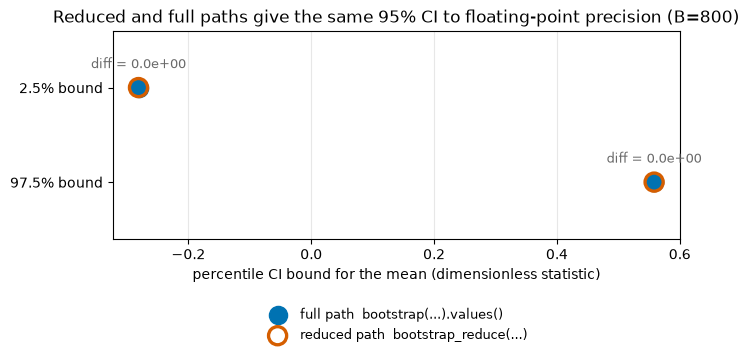

In [10]:
# The two CIs land on top of each other: full path (markers) vs reduced path (open rings).
fig, ax = plt.subplots(figsize=(7, 3.2), layout='constrained')

bounds = ['2.5% bound', '97.5% bound']
ypos = [1, 0]  # draw 2.5% on top, 97.5% below, so the two rows read cleanly
full_vals = [full_lo, full_hi]
red_vals = [float(red_lo), float(red_hi)]

ax.scatter(full_vals, ypos, s=170, color='#0072B2', marker='o',
           label='full path  bootstrap(...).values()', zorder=3)
ax.scatter(red_vals, ypos, s=170, facecolors='none', edgecolors='#D55E00',
           linewidths=2.4, marker='o', label='reduced path  bootstrap_reduce(...)', zorder=4)

for y, fv, rv in zip(ypos, full_vals, red_vals):
    ax.annotate(f'diff = {abs(fv - rv):.1e}', xy=(fv, y), xytext=(0, 14),
                textcoords='offset points', ha='center', fontsize=9, color='dimgray')

ax.set_yticks(ypos)
ax.set_yticklabels(bounds)
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel('percentile CI bound for the mean (dimensionless statistic)')
ax.set_title('Reduced and full paths give the same 95% CI to floating-point precision (B=800)')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.55), ncol=1, frameon=False, fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.show()

## Putting it together

One figure ties the two ideas together. We grow `B` and watch the reduced-path percentile CI for the mean settle as more replicates accumulate, with the large-`B` interval drawn as a band. Each point reuses the same seed, so the curve is itself reproducible.

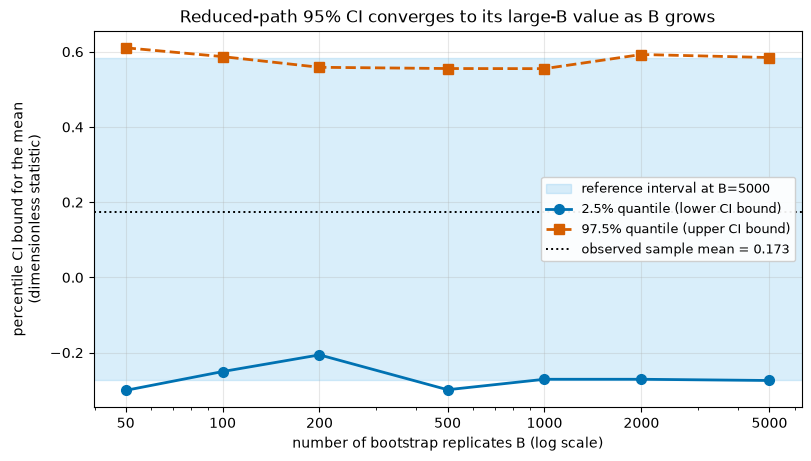

CI at B=  50: [-0.3003, 0.6105]  width 0.9108
CI at B=5000: [-0.2740, 0.5846]  width 0.8586


In [11]:
grid = [50, 100, 200, 500, 1000, 2000, 5000]
los, his = [], []
for b in grid:
    r = bootstrap_reduce(
        x,
        method=MovingBlock(block_length=10),
        statistic=replicate_mean,
        n_bootstraps=b,
        random_state=0,
    )
    lo_b, hi_b = r.quantile([0.025, 0.975])
    los.append(float(lo_b))
    his.append(float(hi_b))

los = np.asarray(los)
his = np.asarray(his)

fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')

# Reference band: the large-B interval the curves are converging toward.
ax.axhspan(lo, hi, color='#56B4E9', alpha=0.22, zorder=0,
           label=f'reference interval at B={B_large}')

# The reduced-path CI bounds as they accumulate replicates.
ax.plot(grid, los, 'o-', color='#0072B2', lw=2, markersize=7,
        label='2.5% quantile (lower CI bound)')
ax.plot(grid, his, 's--', color='#D55E00', lw=2, markersize=7,
        label='97.5% quantile (upper CI bound)')
ax.axhline(x.mean(), color='black', lw=1.4, ls=':', zorder=2,
           label=f'observed sample mean = {x.mean():.3f}')

ax.set_xscale('log')
ax.set_xticks(grid)
ax.set_xticklabels(grid)
ax.set_xlabel('number of bootstrap replicates B (log scale)')
ax.set_ylabel('percentile CI bound for the mean\n(dimensionless statistic)')
ax.set_title('Reduced-path 95% CI converges to its large-B value as B grows')
ax.legend(loc='center right', fontsize=9, framealpha=0.92)
ax.grid(alpha=0.3)
plt.show()

print(f'CI at B={grid[0]:>4d}: [{los[0]:.4f}, {his[0]:.4f}]  width {his[0]-los[0]:.4f}')
print(f'CI at B={grid[-1]:>4d}: [{los[-1]:.4f}, {his[-1]:.4f}]  width {his[-1]-los[-1]:.4f}')

## Closing the loop on reproducibility

A fixed integer seed gives bitwise-identical results no matter how the work is parallelised. Every run records the entropy and the library versions needed to replay or cite it. And `bootstrap_reduce` scales the replicate count to whatever your calibration needs without holding the full `(B, n)` array in memory, while returning the same quantiles the full array would.